# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
269,0.009016,-0.044642,-0.032073,-0.026328,0.042462,-0.010395,0.159089,-0.076395,-0.011897,-0.038357,87.0
182,0.045341,0.050680,0.005650,0.056301,0.064477,0.089186,-0.039719,0.071210,0.015568,-0.009362,138.0
177,0.048974,-0.044642,0.027206,-0.025191,0.023198,0.018414,-0.061809,0.080066,0.072222,0.032059,225.0
301,-0.001882,0.050680,-0.024529,0.052858,0.027326,0.030001,0.030232,-0.002592,-0.021395,0.036201,65.0
404,-0.016412,-0.044642,0.054152,0.070072,-0.033216,-0.027931,0.008142,-0.039493,-0.027129,-0.009362,293.0
332,0.030811,-0.044642,0.104809,0.076958,-0.011201,-0.011335,-0.058127,0.034309,0.057108,0.036201,270.0
352,0.012648,0.050680,-0.071952,-0.046985,-0.051103,-0.097137,0.118591,-0.076395,-0.020292,-0.038357,77.0
123,0.005383,0.050680,0.034751,-0.001091,0.152538,0.198788,-0.061809,0.185234,0.015568,0.073480,84.0
258,0.078034,0.050680,-0.024529,-0.042406,0.006687,0.052861,-0.069172,0.080804,-0.037129,0.056912,89.0
341,0.030811,0.050680,0.059541,0.056301,-0.022208,0.001191,-0.032356,-0.002592,-0.024795,-0.017646,263.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
for col in data.columns:
    valores_faltantes = data[col].isnull().sum()
    print(f'Columna: {col}, Valores faltantes: {valores_faltantes}')

Columna: age, Valores faltantes: 0
Columna: sex, Valores faltantes: 0
Columna: bmi, Valores faltantes: 44
Columna: bp, Valores faltantes: 44
Columna: s1, Valores faltantes: 0
Columna: s2, Valores faltantes: 0
Columna: s3, Valores faltantes: 0
Columna: s4, Valores faltantes: 0
Columna: s5, Valores faltantes: 0
Columna: s6, Valores faltantes: 0
Columna: target, Valores faltantes: 0


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [8]:
imputer_simple = SimpleImputer(strategy='mean')
data['bmi_imputed_simple'] = imputer_simple.fit_transform(data[['bmi']])

print(data[['bmi', 'bmi_imputed_simple']].head(10))

        bmi  bmi_imputed_simple
0  0.061696            0.061696
1 -0.051474           -0.051474
2  0.044451            0.044451
3 -0.011595           -0.011595
4 -0.036385           -0.036385
5 -0.040696           -0.040696
6 -0.047163           -0.047163
7 -0.001895           -0.001895
8  0.061696            0.061696
9       NaN           -0.000205


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:
knn_imputer = KNNImputer(n_neighbors=5)
data_knn = data.copy()
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

# Comparación de estadísticas entre imputación simple y KNN
comparacion = pd.DataFrame({
    'bmi_original': data['bmi'],
    'bmi_simple': data['bmi_imputed_simple'],
    'bmi_knn': data_knn['bmi']
})
print(comparacion.describe())

       bmi_original  bmi_simple     bmi_knn
count    398.000000  442.000000  442.000000
mean      -0.000205   -0.000205    0.000213
std        0.046989    0.044583    0.045416
min       -0.089197   -0.089197   -0.089197
25%       -0.035037   -0.030996   -0.032073
50%       -0.007284   -0.000817   -0.005128
75%        0.030440    0.024781    0.030440
max        0.160855    0.160855    0.160855


#### La imputación simple usa un único valor *(la media)* para todos los faltantes, mientras que KNNImputer estima cada valor faltante usando los vecinos más cercanos, respetando mejor la relación entre variables.

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

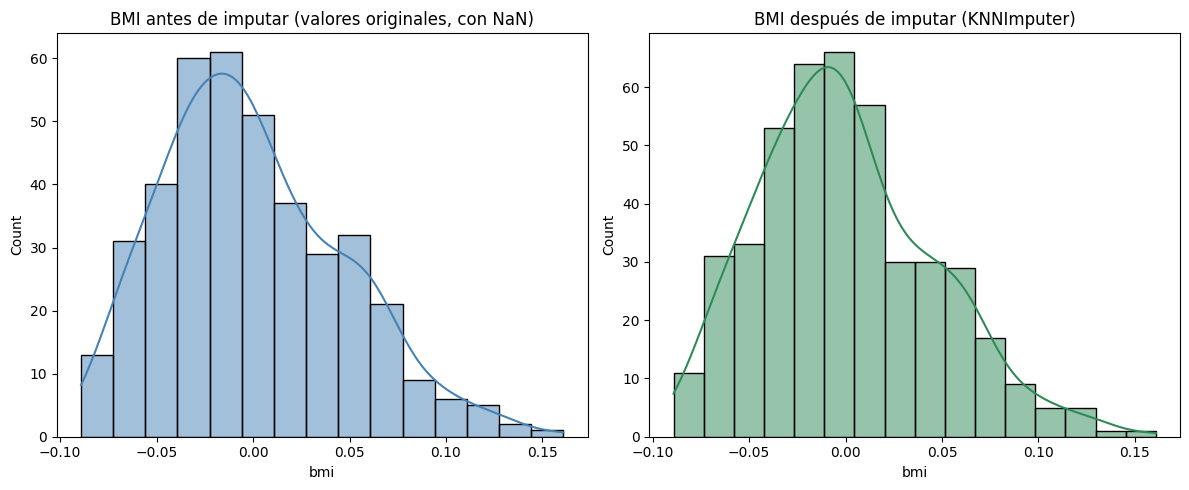

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data['bmi'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BMI antes de imputar (valores originales, con NaN)')

sns.histplot(data_knn['bmi'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('BMI después de imputar (KNNImputer)')

plt.tight_layout()
plt.show()